# ✍️ Handwritten Digit Classification — CNN vs RNN
## MNIST Dataset | Deep Learning Assignment

**Goal:** Classify handwritten digits (0-9) using both CNN and RNN architectures, then compare their performance.

**Dataset:** MNIST — 28x28 grayscale images of handwritten digits

---

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Load MNIST Dataset

In [2]:
# image ko tensor banao aur normalize karo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # grayscale hai isliye sirf 1 value
])

trainset = MNIST(root="./data", train=True, download=True, transform=transform)
testset = MNIST(root="./data", train=False, download=True, transform=transform)

print('Training images:', len(trainset))
print('Testing images :', len(testset))
print('Image shape    :', trainset[0][0].shape)   # (1, 28, 28) -> 1 channel, 28x28 pixels

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]

Training images: 60000
Testing images : 10000
Image shape    : torch.Size([1, 28, 28])


In [3]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

## 3. Visualize Sample Digits

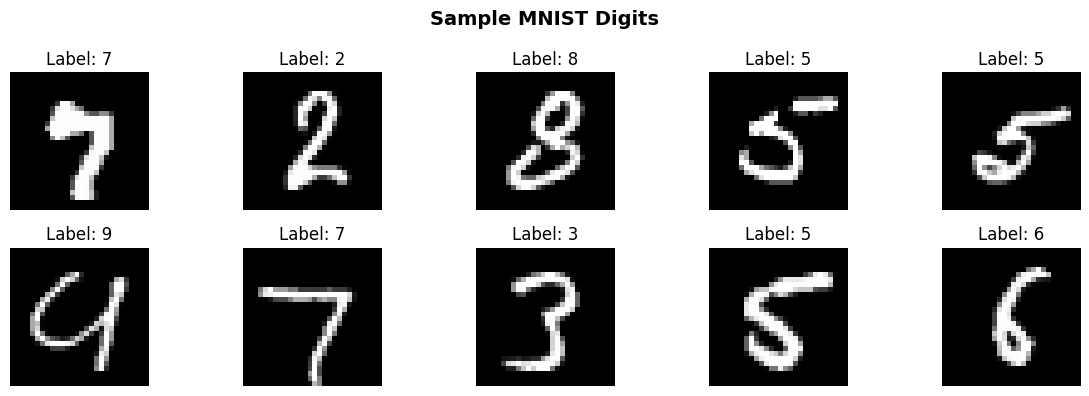

In [4]:
data_iter = iter(trainloader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')   # squeeze() -> (1,28,28) ko (28,28) karta hai
    plt.title(f'Label: {labels[i].item()}')
    plt.axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. CNN Model

CNN images ke liye best hota hai — 2D filters lagata hai jo spatial patterns (edges, curves) pakadte hain.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 1 channel (grayscale) -> 32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                              # 14x14 -> 7x7
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(7 * 7 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, 10)    # 10 digits (0-9)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.fc_layers(x)
        return x


cnn_model = CNN().to(device)
print(cnn_model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. RNN Model

RNN normally sequence data (text, time-series) ke liye hota hai. Image ko hum **row-by-row sequence** maan ke dete hain — har row ek "time step" hai (28 rows = 28 time steps, har row mein 28 pixels = input size).

In [6]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.hidden_size = 128

        # input_size=28 -> har row mein 28 pixels
        # batch_first=True -> input shape (batch, seq, features)
        self.lstm = nn.LSTM(input_size=28, hidden_size=self.hidden_size,
                            num_layers=2, batch_first=True)

        self.fc = nn.Linear(self.hidden_size, 10)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28) -> (batch, 28, 28) banao
        x = x.squeeze(1)

        out, (hidden, cell) = self.lstm(x)
        # out shape: (batch, 28, hidden_size) -> sirf last time step ka output lo
        out = out[:, -1, :]
        out = self.fc(out)
        return out


rnn_model = RNN().to(device)
print(rnn_model)

RNN(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


## 6. Training Function (Both Models Ke Liye Common)

In [7]:
def train_model(model, trainloader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            output = model.forward(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(trainloader)
        loss_history.append(avg_loss)
        print(f"epoch={epoch+1}/{epochs} & loss={avg_loss:.4f}")

    return loss_history

## 7. Train CNN

In [8]:
print('Training CNN...')
cnn_loss_history = train_model(cnn_model, trainloader, epochs=5)

Training CNN...
epoch=1/5 & loss=0.1536
epoch=2/5 & loss=0.0444
epoch=3/5 & loss=0.0322
epoch=4/5 & loss=0.0233
epoch=5/5 & loss=0.0176


## 8. Train RNN

In [9]:
print('Training RNN...')
rnn_loss_history = train_model(rnn_model, trainloader, epochs=5)

Training RNN...
epoch=1/5 & loss=0.3732
epoch=2/5 & loss=0.0974
epoch=3/5 & loss=0.0667
epoch=4/5 & loss=0.0517
epoch=5/5 & loss=0.0441


## 9. Loss Comparison Graph

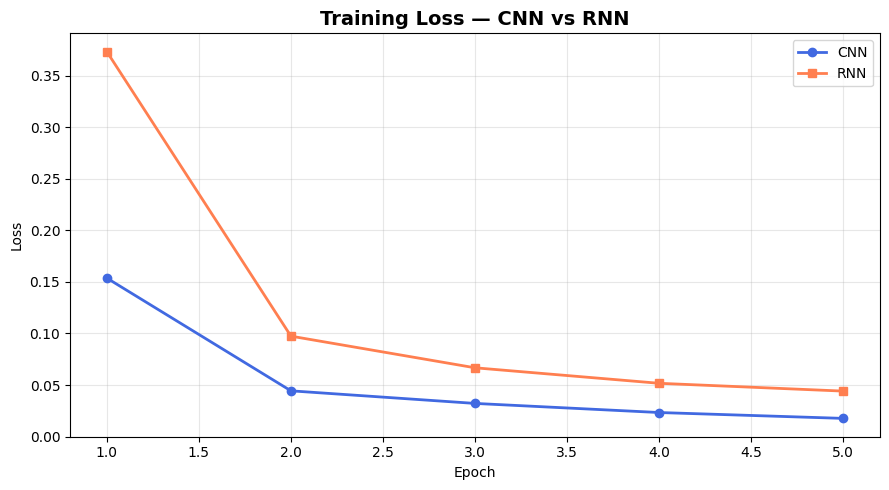

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, 6), cnn_loss_history, marker='o', label='CNN', color='royalblue', linewidth=2)
plt.plot(range(1, 6), rnn_loss_history, marker='s', label='RNN', color='coral', linewidth=2)
plt.title('Training Loss — CNN vs RNN', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Evaluation Function

In [11]:
def evaluate_model(model, testloader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model.forward(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total * 100
    return accuracy, all_preds, all_labels

In [12]:
cnn_accuracy, cnn_preds, cnn_labels = evaluate_model(cnn_model, testloader)
rnn_accuracy, rnn_preds, rnn_labels = evaluate_model(rnn_model, testloader)

print(f'CNN Test Accuracy: {cnn_accuracy:.2f}%')
print(f'RNN Test Accuracy: {rnn_accuracy:.2f}%')

CNN Test Accuracy: 98.54%
RNN Test Accuracy: 98.59%


## 11. Confusion Matrix — CNN vs RNN

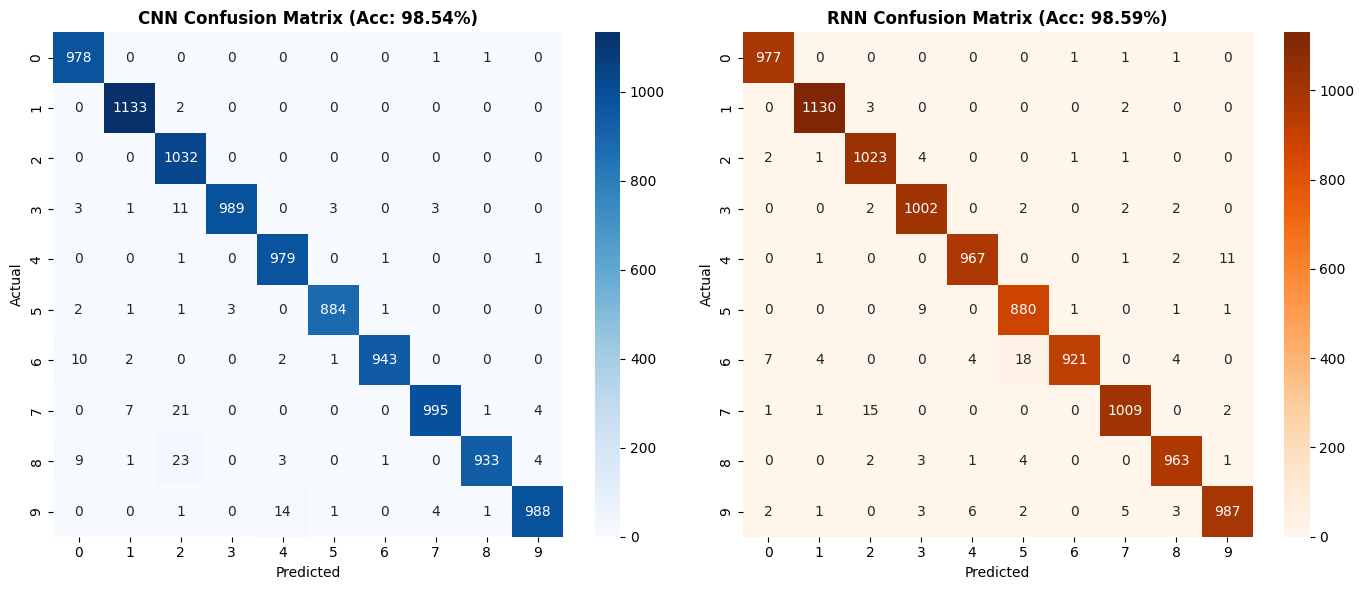

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'CNN Confusion Matrix (Acc: {cnn_accuracy:.2f}%)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rnn = confusion_matrix(rnn_labels, rnn_preds)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'RNN Confusion Matrix (Acc: {rnn_accuracy:.2f}%)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 12. Accuracy Comparison Bar Chart

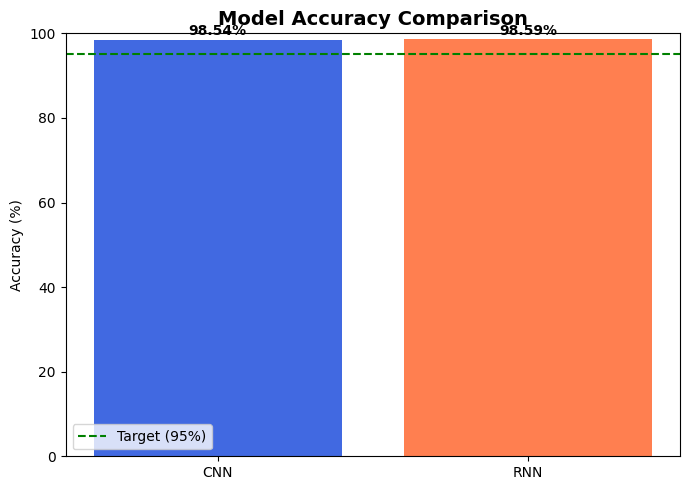

In [14]:
plt.figure(figsize=(7, 5))
models = ['CNN', 'RNN']
accuracies = [cnn_accuracy, rnn_accuracy]
colors = ['royalblue', 'coral']

bars = plt.bar(models, accuracies, color=colors)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.axhline(y=95, color='green', linestyle='--', label='Target (95%)')
plt.legend()

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Classification Reports

In [15]:
print('CNN Classification Report:')
print(classification_report(cnn_labels, cnn_preds))

print('\nRNN Classification Report:')
print(classification_report(rnn_labels, rnn_preds))

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.95      1.00      0.97      1032
           3       1.00      0.98      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.97      0.98      1028
           8       1.00      0.96      0.98       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


RNN Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98

## 14. Sample Predictions Comparison

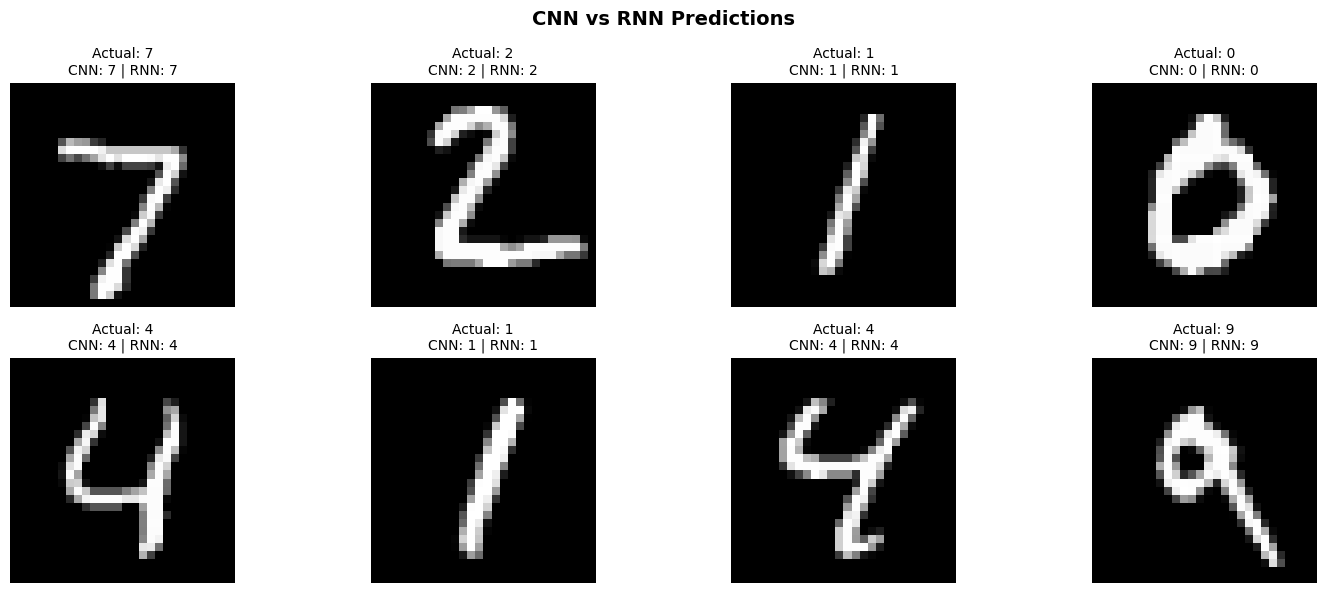

In [16]:
data_iter = iter(testloader)
images, labels = next(data_iter)
images_gpu = images.to(device)

with torch.no_grad():
    cnn_out = cnn_model.forward(images_gpu)
    _, cnn_pred = torch.max(cnn_out, 1)

    rnn_out = rnn_model.forward(images_gpu)
    _, rnn_pred = torch.max(rnn_out, 1)

plt.figure(figsize=(15, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')

    actual = labels[i].item()
    cnn_p = cnn_pred[i].cpu().item()
    rnn_p = rnn_pred[i].cpu().item()

    plt.title(f'Actual: {actual}\nCNN: {cnn_p} | RNN: {rnn_p}', fontsize=10)
    plt.axis('off')

plt.suptitle('CNN vs RNN Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Final Summary

| Model | Accuracy | Architecture |
|-------|----------|---------------|
| CNN | See above | 2 Conv layers + 2 FC layers |
| RNN (LSTM) | See above | 2-layer LSTM + 1 FC layer |

### Key Observations:
- **CNN** generally performs better on images because it captures **spatial patterns** (edges, curves, shapes) using 2D filters.
- **RNN** treats the image as a sequence of rows, which is not its natural strength — RNNs are designed for sequential/temporal data like text or time-series.
- Both models can reach >95% accuracy on MNIST since it's a relatively simple dataset, but CNN usually converges faster and achieves slightly higher accuracy.
- Confusion matrices show which digits are commonly confused (e.g., 4 vs 9, 3 vs 8) due to similar visual structure.

---
*Built with PyTorch — CNN vs RNN comparison for handwritten digit classification*